<a href="https://colab.research.google.com/github/ArthTechX/Diffusion-Language-Models/blob/main/week2_dasg_drift_probes_fixed_vs_adaptive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 — DASG Drift Probes and Fixed-vs-Adaptive Layer Selection

This notebook implements Week 2 properly:

- hidden-state drift
- logit KL drift
- layer ranking with low/mid/high timestep-noise bins
- drift heatmap values and plots
- first fixed-vs-adaptive layer-selection experiment

It is designed to run on free Google Colab T4 using `inclusionAI/LLaDA-MoE-7B-A1B-Instruct` in 4-bit NF4.

The experiment uses a small target toy-code domain and a small general-retention domain, matching the Week 1 setup.


## 0. GPU check

In [1]:
!nvidia-smi

Sat Jul  4 06:09:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   42C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 1. Install dependencies

Run this once, then restart runtime if Colab asks you to.


In [2]:
!pip uninstall -y transformers tokenizers -q

!pip -q install --no-cache-dir   "transformers>=4.45.0,<5.0.0"   "bitsandbytes>=0.46.1"   accelerate   safetensors   sentencepiece   einops   huggingface_hub   pandas   matplotlib   numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 115.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 211.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 277.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 135.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 6.19.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


## 2. Imports and config

In [3]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import gc
import json
import math
import time
import random
from pathlib import Path
from contextlib import contextmanager

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from transformers import AutoTokenizer, AutoModel, BitsAndBytesConfig

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

MODEL_NAME = "inclusionAI/LLaDA-MoE-7B-A1B-Instruct"
MASK_ID = 156895
MAX_LENGTH = 32

# Keep small for free Colab T4.
PROBE_TRAIN_STEPS = 5
STRATEGY_TRAIN_STEPS = 3
LR = 2e-4
LAMBDA_RET = 0.5

LORA_RANK = 4
LORA_ALPHA = 8
LORA_DROPOUT = 0.05

TOP_LAYER_BUDGET = 5

NOISE_BINS = {
    "low_noise": 0.15,
    "mid_noise": 0.50,
    "high_noise": 0.85,
}

NOISE_ORDER = ["low_noise", "mid_noise", "high_noise"]

NOISE_BIN_TO_IDX = {
    "low_noise": 0,
    "mid_noise": 1,
    "high_noise": 2,
}

TARGET_TEXTS = [
    "def add_numbers(a, b): return a + b",
    "for i in range(n): total += arr[i]",
    "A binary search repeatedly halves the search interval.",
    "The function computes the maximum subarray sum using dynamic programming.",
    "class Queue: def __init__(self): self.items = []",
]

RETENTION_TEXTS = [
    "The city library opens every morning.",
    "Students learn better when examples are clear and practice is consistent.",
    "A healthy diet includes fruits, vegetables, grains, and enough water.",
]

OUT_DIR = Path("/content/week2_dasg_drift_probes")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Output dir:", OUT_DIR)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

Output dir: /content/week2_dasg_drift_probes
GPU: Tesla T4


## 3. Load tokenizer and base model helpers

In [4]:
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
)

print("Tokenizer loaded:", MODEL_NAME)


def cleanup_model():
    global model
    try:
        del model
    except Exception:
        pass
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def load_base_model():
    cleanup_model()

    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_use_double_quant=True,
    )

    base = AutoModel.from_pretrained(
        MODEL_NAME,
        trust_remote_code=True,
        quantization_config=bnb_config,
        device_map="auto",
        max_memory={0: "13GiB", "cpu": "25GiB"},
        low_cpu_mem_usage=True,
    )

    base.eval()
    return base


def get_input_device(model):
    try:
        return model.get_input_embeddings().weight.device
    except Exception:
        pass

    if hasattr(model, "device"):
        return model.device

    for p in model.parameters():
        return p.device

    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def gpu_mem_gb():
    if not torch.cuda.is_available():
        return 0.0
    return torch.cuda.max_memory_allocated() / 1024**3


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

Tokenizer loaded: inclusionAI/LLaDA-MoE-7B-A1B-Instruct


## 4. Token masking and forward helpers

In [5]:
def encode_text(text, model):
    input_device = get_input_device(model)

    batch = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH,
    )

    input_ids = batch["input_ids"].to(input_device)

    if "attention_mask" in batch:
        attention_mask = batch["attention_mask"].to(input_device)
    else:
        attention_mask = torch.ones_like(input_ids)

    return input_ids, attention_mask


def make_masked_input(clean_ids, attention_mask, mask_prob):
    rand = torch.rand(clean_ids.shape, device=clean_ids.device)
    valid = attention_mask.bool()

    masked_indices = (rand < mask_prob) & valid

    if not masked_indices.any():
        masked_indices[0, -1] = True

    noisy_ids = torch.where(
        masked_indices,
        torch.full_like(clean_ids, MASK_ID),
        clean_ids,
    )

    return noisy_ids, masked_indices


def get_logits_from_output(out):
    if hasattr(out, "logits"):
        return out.logits

    if isinstance(out, (tuple, list)):
        return out[0]

    return out


def forward_logits(model, input_ids):
    out = model(input_ids=input_ids)
    return get_logits_from_output(out)


def masked_weighted_ce(logits, labels, masked_indices, mask_prob):
    if masked_indices.sum().item() == 0:
        zero = torch.tensor(0.0, device=logits.device)
        return zero, zero

    logits_m = logits[masked_indices].float()
    labels_m = labels[masked_indices]

    ce = F.cross_entropy(logits_m, labels_m)
    weighted = ce / mask_prob

    return weighted, ce


def teacher_agreement(student_logits, teacher_logits, masked_indices):
    if masked_indices.sum().item() == 0:
        return float("nan")

    student_pred = student_logits.argmax(dim=-1)
    teacher_pred = teacher_logits.argmax(dim=-1)

    return (
        student_pred[masked_indices] == teacher_pred[masked_indices]
    ).float().mean().item()

## 5. Minimal trainable LoRA wrapper

This is used for the warm-start probe and the fixed-vs-adaptive layer-selection experiment.

The frozen base path is obtained by disabling adapters.


In [6]:
class ProbeLoRALinear(nn.Module):
    def __init__(self, base_layer, r=4, lora_alpha=8, lora_dropout=0.05):
        super().__init__()

        if not hasattr(base_layer, "in_features") or not hasattr(base_layer, "out_features"):
            raise ValueError("Base layer must expose in_features and out_features.")

        self.base_layer = base_layer
        self.in_features = int(base_layer.in_features)
        self.out_features = int(base_layer.out_features)
        self.r = int(r)
        self.scaling = float(lora_alpha) / float(r)
        self.adapter_disabled = False

        for p in self.base_layer.parameters():
            p.requires_grad = False

        try:
            device = base_layer.weight.device
        except Exception:
            device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        self.lora_A = nn.Linear(self.in_features, self.r, bias=False).to(device=device, dtype=torch.float32)
        self.lora_B = nn.Linear(self.r, self.out_features, bias=False).to(device=device, dtype=torch.float32)
        self.dropout = nn.Dropout(lora_dropout)

        nn.init.kaiming_uniform_(self.lora_A.weight, a=math.sqrt(5))
        nn.init.zeros_(self.lora_B.weight)

    def forward(self, x, *args, **kwargs):
        base_out = self.base_layer(x, *args, **kwargs)

        if self.adapter_disabled:
            return base_out

        x_lora = x.to(self.lora_A.weight.dtype)
        delta = self.lora_B(self.lora_A(self.dropout(x_lora))) * self.scaling
        delta = delta.to(base_out.dtype)

        return base_out + delta


def iter_probe_modules(model):
    for module in model.modules():
        if isinstance(module, ProbeLoRALinear):
            yield module


@contextmanager
def disable_adapters(model):
    modules = list(iter_probe_modules(model))
    old_values = [m.adapter_disabled for m in modules]

    try:
        for m in modules:
            m.adapter_disabled = True
        yield
    finally:
        for m, old in zip(modules, old_values):
            m.adapter_disabled = old

## 6. Find model layers and attach LoRA probe modules

In [7]:
def extract_layer_id(module_name):
    parts = module_name.split(".")

    for i, part in enumerate(parts):
        if part in ["layers", "blocks", "h", "decoder_layers"]:
            if i + 1 < len(parts) and parts[i + 1].isdigit():
                return int(parts[i + 1])

    for part in parts:
        if part.isdigit():
            value = int(part)
            if 0 <= value <= 200:
                return value

    return None


def find_all_layer_ids(model):
    ids = set()
    for name, module in model.named_modules():
        layer_id = extract_layer_id(name)
        if layer_id is not None:
            ids.add(layer_id)
    return sorted(ids)


def find_linear_modules_for_layers(model, selected_layers):
    selected_layers = set(selected_layers)

    # Keep Week 2 safe on T4: use attention projections first.
    preferred_leaf_names = {
        "q_proj",
        "k_proj",
        "v_proj",
        "o_proj",
    }

    target_names = []

    for name, module in model.named_modules():
        if name == "":
            continue

        cls_name = module.__class__.__name__.lower()
        leaf = name.split(".")[-1]
        layer_id = extract_layer_id(name)

        is_linear_like = (
            "linear" in cls_name
            and hasattr(module, "in_features")
            and hasattr(module, "out_features")
        )

        if is_linear_like and layer_id in selected_layers and leaf in preferred_leaf_names:
            target_names.append(name)

    return sorted(target_names)


def get_child(parent, key):
    if key.isdigit() and isinstance(parent, (nn.ModuleList, nn.Sequential)):
        return parent[int(key)]
    return getattr(parent, key)


def set_child(parent, key, value):
    if key.isdigit() and isinstance(parent, (nn.ModuleList, nn.Sequential)):
        parent[int(key)] = value
    else:
        setattr(parent, key, value)


def get_parent_and_key(root, module_name):
    parts = module_name.split(".")
    parent = root

    for p in parts[:-1]:
        parent = get_child(parent, p)

    return parent, parts[-1]


def attach_probe_lora(model, selected_layers):
    for p in model.parameters():
        p.requires_grad = False

    target_names = find_linear_modules_for_layers(model, selected_layers)

    if len(target_names) == 0:
        print("No target modules found. Showing first linear-like modules for debugging:")
        shown = 0
        for name, module in model.named_modules():
            cls_name = module.__class__.__name__.lower()
            if "linear" in cls_name and hasattr(module, "in_features") and hasattr(module, "out_features"):
                print(name, "->", module.__class__.__name__)
                shown += 1
                if shown >= 80:
                    break
        raise RuntimeError("No selected linear modules found.")

    for name in target_names:
        parent, key = get_parent_and_key(model, name)
        old_module = get_child(parent, key)

        wrapped = ProbeLoRALinear(
            old_module,
            r=LORA_RANK,
            lora_alpha=LORA_ALPHA,
            lora_dropout=LORA_DROPOUT,
        )

        set_child(parent, key, wrapped)

    return target_names


# Inspect once.
inspect_model = load_base_model()
ALL_LAYER_IDS = find_all_layer_ids(inspect_model)
print("Detected layer ids:", ALL_LAYER_IDS)
print("Num layers detected:", len(ALL_LAYER_IDS))
print("Example target modules across all layers:")
example_targets = find_linear_modules_for_layers(inspect_model, ALL_LAYER_IDS)
print("Num target modules:", len(example_targets))
for x in example_targets[:30]:
    print(x)
cleanup_model()

config.json: 0.00B [00:00, ?B/s]

configuration_lladamoe.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/inclusionAI/LLaDA-MoE-7B-A1B-Instruct:
- configuration_lladamoe.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_lladamoe.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/inclusionAI/LLaDA-MoE-7B-A1B-Instruct:
- modeling_lladamoe.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


...

model-00002-of-00003.safetensors:   0%|          | 0.00/5.00G [00:00<?, ?B/s]

model-00003-of-00003.safetensors:   0%|          | 0.00/4.72G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Detected layer ids: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Num layers detected: 16
Example target modules across all layers:
Num target modules: 64
model.layers.0.self_attn.k_proj
model.layers.0.self_attn.o_proj
model.layers.0.self_attn.q_proj
model.layers.0.self_attn.v_proj
model.layers.1.self_attn.k_proj
model.layers.1.self_attn.o_proj
model.layers.1.self_attn.q_proj
model.layers.1.self_attn.v_proj
model.layers.10.self_attn.k_proj
model.layers.10.self_attn.o_proj
model.layers.10.self_attn.q_proj
model.layers.10.self_attn.v_proj
model.layers.11.self_attn.k_proj
model.layers.11.self_attn.o_proj
model.layers.11.self_attn.q_proj
model.layers.11.self_attn.v_proj
model.layers.12.self_attn.k_proj
model.layers.12.self_attn.o_proj
model.layers.12.self_attn.q_proj
model.layers.12.self_attn.v_proj
model.layers.13.self_attn.k_proj
model.layers.13.self_attn.o_proj
model.layers.13.self_attn.q_proj
model.layers.13.self_attn.v_proj
model.layers.14.self_attn.k_proj
model.layers.14.sel

## 7. Train all-layer LoRA probe

This warm-start probe creates the adapted path used for drift measurement.


In [8]:
def compute_target_loss(model, text, noise_bin):
    mask_prob = NOISE_BINS[noise_bin]

    input_ids, attention_mask = encode_text(text, model)
    noisy_ids, masked_indices = make_masked_input(input_ids, attention_mask, mask_prob)

    logits = forward_logits(model, noisy_ids)
    weighted_loss, ce_loss = masked_weighted_ce(logits, input_ids, masked_indices, mask_prob)

    return weighted_loss, ce_loss, int(masked_indices.sum().item())


def compute_retention_kl(model, text, noise_bin):
    mask_prob = NOISE_BINS[noise_bin]

    input_ids, attention_mask = encode_text(text, model)
    noisy_ids, masked_indices = make_masked_input(input_ids, attention_mask, mask_prob)

    with torch.no_grad():
        with disable_adapters(model):
            base_logits = forward_logits(model, noisy_ids).float()

    probe_logits = forward_logits(model, noisy_ids).float()

    if masked_indices.sum().item() == 0:
        zero = torch.tensor(0.0, device=get_input_device(model))
        return zero, 0

    base_log_probs = F.log_softmax(base_logits[masked_indices], dim=-1)
    probe_log_probs = F.log_softmax(probe_logits[masked_indices], dim=-1)
    base_probs = base_log_probs.exp()

    kl = F.kl_div(probe_log_probs, base_probs, reduction="batchmean") / mask_prob
    return kl, int(masked_indices.sum().item())


def train_probe(model):
    model.train()

    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=LR,
    )

    rows = []

    for step in range(PROBE_TRAIN_STEPS):
        noise_bin = random.choice(NOISE_ORDER)
        target_text = random.choice(TARGET_TEXTS)
        retention_text = random.choice(RETENTION_TEXTS)

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats()

        start = time.time()

        target_loss, target_ce, target_masked = compute_target_loss(model, target_text, noise_bin)
        retention_kl, retention_masked = compute_retention_kl(model, retention_text, noise_bin)

        total_loss = target_loss + LAMBDA_RET * retention_kl

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        elapsed = time.time() - start

        row = {
            "step": step,
            "noise_bin": noise_bin,
            "mask_prob": NOISE_BINS[noise_bin],
            "target_text": target_text,
            "retention_text": retention_text,
            "target_ce_loss": float(target_ce.detach().cpu()),
            "target_weighted_loss": float(target_loss.detach().cpu()),
            "retention_kl_loss": float(retention_kl.detach().cpu()),
            "total_loss": float(total_loss.detach().cpu()),
            "target_masked_tokens": target_masked,
            "retention_masked_tokens": retention_masked,
            "trainable_params": count_trainable_params(model),
            "peak_gpu_memory_gb": gpu_mem_gb(),
            "elapsed_sec": elapsed,
        }

        rows.append(row)
        print(row)

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    return rows


model = load_base_model()
probe_layers = ALL_LAYER_IDS
probe_targets = attach_probe_lora(model, probe_layers)
print("Probe LoRA attached to layers:", probe_layers)
print("Num probe target modules:", len(probe_targets))
print("Trainable params:", count_trainable_params(model))

probe_train_rows = train_probe(model)
probe_train_df = pd.DataFrame(probe_train_rows)
probe_train_path = OUT_DIR / "week2_lora_probe_train_log.csv"
probe_train_df.to_csv(probe_train_path, index=False)
print("Saved:", probe_train_path)
display(probe_train_df)

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Probe LoRA attached to layers: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]
Num probe target modules: 64
Trainable params: 1048576


/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


{'step': 0, 'noise_bin': 'high_noise', 'mask_prob': 0.85, 'target_text': 'def add_numbers(a, b): return a + b', 'retention_text': 'The city library opens every morning.', 'target_ce_loss': 4.014774322509766, 'target_weighted_loss': 4.723264217376709, 'retention_kl_loss': 0.19320441782474518, 'total_loss': 4.81986665725708, 'target_masked_tokens': 8, 'retention_masked_tokens': 4, 'trainable_params': 1048576, 'peak_gpu_memory_gb': 8.956017017364502, 'elapsed_sec': 6.0233306884765625}
{'step': 1, 'noise_bin': 'high_noise', 'mask_prob': 0.85, 'target_text': 'A binary search repeatedly halves the search interval.', 'retention_text': 'The city library opens every morning.', 'target_ce_loss': 8.352956771850586, 'target_weighted_loss': 9.827008247375488, 'retention_kl_loss': 0.5128251314163208, 'total_loss': 10.083420753479004, 'target_masked_tokens': 7, 'retention_masked_tokens': 6, 'trainable_params': 1048576, 'peak_gpu_memory_gb': 8.975888729095459, 'elapsed_sec': 4.89275598526001}
{'step':

,step,noise_bin,mask_prob,target_text,retention_text,target_ce_loss,target_weighted_loss,retention_kl_loss,total_loss,target_masked_tokens,retention_masked_tokens,trainable_params,peak_gpu_memory_gb,elapsed_sec
0,0,high_noise,0.85,"def add_numbers(a, b): return a + b",The city library opens every morning.,4.014774,4.723264,0.193204,4.819867,8,4,1048576,8.956017,6.023331
1,1,high_noise,0.85,A binary search repeatedly halves the search i...,The city library opens every morning.,8.352957,9.827008,0.512825,10.083421,7,6,1048576,8.975889,4.892756
2,2,low_noise,0.15,for i in range(n): total += arr[i],"A healthy diet includes fruits, vegetables, gr...",1.348887,8.992580,0.213698,9.099429,1,2,1048576,8.994305,5.163507
3,3,low_noise,0.15,class Queue: def __init__(self): self.items = [],The city library opens every morning.,0.267218,1.781451,1.430080,2.496491,4,1,1048576,8.969005,5.444054
4,4,high_noise,0.85,The function computes the maximum subarray sum...,The city library opens every morning.,4.807889,5.656340,0.310098,5.811389,9,4,1048576,8.979325,4.629225


## 8. Hidden-state and logit KL drift functions

In [9]:
def forward_with_hidden_states(model, input_ids):
    out = model(
        input_ids=input_ids,
        output_hidden_states=True,
        return_dict=True,
    )

    logits = get_logits_from_output(out)

    if not hasattr(out, "hidden_states") or out.hidden_states is None:
        raise RuntimeError(
            "Model did not return hidden_states. Use a hook-based extraction fallback for this model."
        )

    return logits, out.hidden_states


@torch.no_grad()
def compute_base_and_probe_outputs(model, noisy_ids):
    with disable_adapters(model):
        base_logits, base_hidden = forward_with_hidden_states(model, noisy_ids)

    probe_logits, probe_hidden = forward_with_hidden_states(model, noisy_ids)

    return base_logits, base_hidden, probe_logits, probe_hidden


@torch.no_grad()
def compute_drift_for_text(model, domain, text, noise_bin):
    model.eval()

    mask_prob = NOISE_BINS[noise_bin]

    input_ids, attention_mask = encode_text(text, model)
    noisy_ids, masked_indices = make_masked_input(input_ids, attention_mask, mask_prob)

    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    start = time.time()

    base_logits, base_hidden, probe_logits, probe_hidden = compute_base_and_probe_outputs(model, noisy_ids)

    elapsed = time.time() - start

    base_logits = base_logits.float()
    probe_logits = probe_logits.float()

    if masked_indices.sum().item() > 0:
        base_log_probs = F.log_softmax(base_logits[masked_indices], dim=-1)
        probe_log_probs = F.log_softmax(probe_logits[masked_indices], dim=-1)
        base_probs = base_log_probs.exp()

        # KL(base || probe), using probe as the adapted path.
        logit_kl = F.kl_div(
            probe_log_probs,
            base_probs,
            reduction="batchmean",
        ).item()

        agreement = teacher_agreement(probe_logits, base_logits, masked_indices)
    else:
        logit_kl = float("nan")
        agreement = float("nan")

    rows = []
    valid = attention_mask.bool()

    for hidden_idx, (h_base, h_probe) in enumerate(zip(base_hidden, probe_hidden)):
        # hidden_idx=0 is embedding output, block_id starts at 0 after that.
        block_id = hidden_idx - 1

        diff = (h_probe.float() - h_base.float()) ** 2
        valid_expanded = valid.unsqueeze(-1).expand_as(diff)
        hidden_drift = diff[valid_expanded].mean().item()

        rows.append({
            "domain": domain,
            "text": text,
            "noise_bin": noise_bin,
            "mask_prob": mask_prob,
            "hidden_state_index": hidden_idx,
            "block_id": block_id,
            "hidden_drift_mse": hidden_drift,
            "logit_kl_base_to_probe": logit_kl,
            "teacher_agreement": agreement,
            "masked_tokens": int(masked_indices.sum().item()),
            "peak_gpu_memory_gb": gpu_mem_gb(),
            "elapsed_sec": elapsed,
        })

    return rows

## 9. Run drift probe and save drift scores

In [10]:
drift_rows = []

for text in TARGET_TEXTS:
    for noise_bin in NOISE_ORDER:
        drift_rows.extend(
            compute_drift_for_text(
                model=model,
                domain="target_code_toy",
                text=text,
                noise_bin=noise_bin,
            )
        )

for text in RETENTION_TEXTS:
    for noise_bin in NOISE_ORDER:
        drift_rows.extend(
            compute_drift_for_text(
                model=model,
                domain="retention_general_toy",
                text=text,
                noise_bin=noise_bin,
            )
        )

# Remove embedding row from layer ranking later, but keep it in raw scores.
drift_df = pd.DataFrame(drift_rows)

drift_path = OUT_DIR / "week2_drift_scores.csv"
drift_df.to_csv(drift_path, index=False)

print("Saved:", drift_path)
print("Rows:", len(drift_df))
display(drift_df.head())

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Saved: /content/week2_dasg_drift_probes/week2_drift_scores.csv
Rows: 408


,domain,text,noise_bin,mask_prob,hidden_state_index,block_id,hidden_drift_mse,logit_kl_base_to_probe,teacher_agreement,masked_tokens,peak_gpu_memory_gb,elapsed_sec
0,target_code_toy,"def add_numbers(a, b): return a + b",low_noise,0.15,0,-1,0.000000e+00,0.016848,1.0,1,8.902645,1.754309
1,target_code_toy,"def add_numbers(a, b): return a + b",low_noise,0.15,1,0,1.067606e-09,0.016848,1.0,1,8.902645,1.754309
2,target_code_toy,"def add_numbers(a, b): return a + b",low_noise,0.15,2,1,4.028653e-09,0.016848,1.0,1,8.902645,1.754309
3,target_code_toy,"def add_numbers(a, b): return a + b",low_noise,0.15,3,2,8.470866e-09,0.016848,1.0,1,8.902645,1.754309
4,target_code_toy,"def add_numbers(a, b): return a + b",low_noise,0.15,4,3,2.147605e-07,0.016848,1.0,1,8.902645,1.754309


## 10. Layer ranking with timestep/noise bins

In [11]:
target_layer_drift = drift_df[
    (drift_df["domain"] == "target_code_toy")
    & (drift_df["block_id"] >= 0)
].copy()

rank_df = (
    target_layer_drift
    .groupby("block_id")
    .agg(
        mean_hidden_drift_mse=("hidden_drift_mse", "mean"),
        max_hidden_drift_mse=("hidden_drift_mse", "max"),
        mean_logit_kl=("logit_kl_base_to_probe", "mean"),
        mean_teacher_agreement=("teacher_agreement", "mean"),
    )
    .reset_index()
)

# Normalize hidden drift for stable ranking display.
def minmax(series):
    lo = series.min()
    hi = series.max()
    if float(hi - lo) == 0.0:
        return series * 0.0
    return (series - lo) / (hi - lo)

rank_df["hidden_drift_norm"] = minmax(rank_df["mean_hidden_drift_mse"])
rank_df["logit_kl_norm"] = minmax(rank_df["mean_logit_kl"].fillna(0.0))

# Logit KL is global per input, so hidden drift is the main layer-specific signal.
rank_df["combined_drift_score"] = rank_df["hidden_drift_norm"] + 0.25 * rank_df["logit_kl_norm"]

rank_df = rank_df.sort_values("combined_drift_score", ascending=False).reset_index(drop=True)

rank_path = OUT_DIR / "week2_layer_ranking.csv"
rank_df.to_csv(rank_path, index=False)

print("Saved:", rank_path)
display(rank_df)

selected_layers = rank_df.head(TOP_LAYER_BUDGET)["block_id"].astype(int).tolist()

selection = {
    "method": "DASG_hidden_state_plus_logit_kl_probe",
    "model_name": MODEL_NAME,
    "top_layer_budget": TOP_LAYER_BUDGET,
    "selected_layers": selected_layers,
    "ranking_rule": "combined_drift_score = normalized_hidden_drift + 0.25 * normalized_logit_KL",
    "note": "Logit KL is measured per timestep/noise bin; hidden-state drift supplies the layer-specific component.",
}

selection_path = OUT_DIR / "selected_grown_layers.json"
with open(selection_path, "w") as f:
    json.dump(selection, f, indent=2)

print("Saved:", selection_path)
print(json.dumps(selection, indent=2))

Saved: /content/week2_dasg_drift_probes/week2_layer_ranking.csv


,block_id,mean_hidden_drift_mse,max_hidden_drift_mse,mean_logit_kl,mean_teacher_agreement,hidden_drift_norm,logit_kl_norm,combined_drift_score
0,15,9.997874e+00,2.566922e+01,0.410852,0.672063,1.000000e+00,0.0,1.000000e+00
1,14,6.051148e-01,2.294180e+00,0.410852,0.672063,6.052435e-02,0.0,6.052435e-02
2,13,1.790283e-01,1.255440e+00,0.410852,0.672063,1.790664e-02,0.0,1.790664e-02
3,12,1.199145e-01,1.064983e+00,0.410852,0.672063,1.199400e-02,0.0,1.199400e-02
4,11,7.577646e-02,6.932083e-01,0.410852,0.672063,7.579256e-03,0.0,7.579256e-03
5,10,7.106525e-02,6.818471e-01,0.410852,0.672063,7.108035e-03,0.0,7.108035e-03
6,9,7.010104e-02,6.794543e-01,0.410852,0.672063,7.011594e-03,0.0,7.011594e-03
7,8,1.807420e-02,1.215629e-01,0.410852,0.672063,1.807803e-03,0.0,1.807803e-03
8,7,3.442173e-04,2.011956e-03,0.410852,0.672063,3.442788e-05,0.0,3.442788e-05
9,6,3.610609e-05,8.067118e-05,0.410852,0.672063,3.610210e-06,0.0,3.610210e-06


Saved: /content/week2_dasg_drift_probes/selected_grown_layers.json
{
  "method": "DASG_hidden_state_plus_logit_kl_probe",
  "model_name": "inclusionAI/LLaDA-MoE-7B-A1B-Instruct",
  "top_layer_budget": 5,
  "selected_layers": [
    15,
    14,
    13,
    12,
    11
  ],
  "ranking_rule": "combined_drift_score = normalized_hidden_drift + 0.25 * normalized_logit_KL",
  "note": "Logit KL is measured per timestep/noise bin; hidden-state drift supplies the layer-specific component."
}


## 11. Drift heatmaps

Saved: /content/week2_dasg_drift_probes/week2_hidden_drift_heatmap_values.csv


noise_bin,low_noise,mid_noise,high_noise
block_id,,,
0,1.849382e-08,1.066671e-08,5.850707e-09
1,8.671430e-08,1.067699e-07,9.614452e-08
2,3.836075e-07,5.258457e-07,3.890180e-07
3,1.195878e-06,1.762633e-06,2.673597e-06
4,3.145194e-06,6.330785e-06,8.731768e-06
5,7.362496e-06,1.785943e-05,2.009470e-05
6,1.928415e-05,3.956713e-05,4.946700e-05
7,4.848169e-05,2.282096e-04,7.559607e-04
8,1.484873e-04,5.148939e-02,2.584720e-03


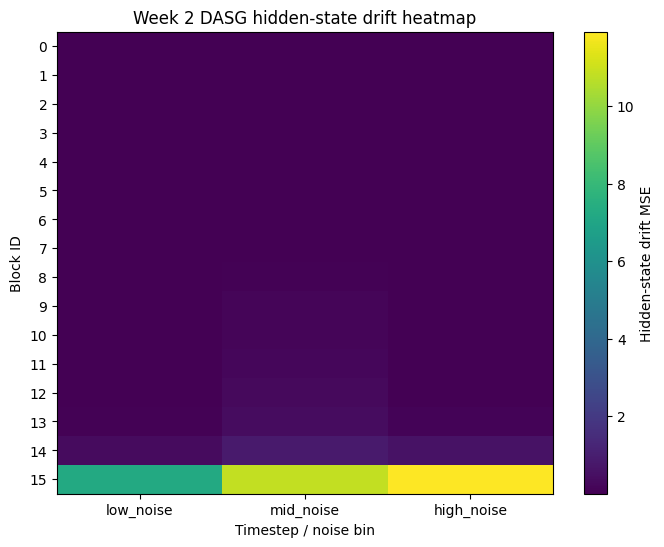

Saved: /content/week2_dasg_drift_probes/week2_logit_kl_heatmap_values.csv


noise_bin,low_noise,mid_noise,high_noise
block_id,,,
0,0.433504,0.423149,0.375902
1,0.433504,0.423149,0.375902
2,0.433504,0.423149,0.375902
3,0.433504,0.423149,0.375902
4,0.433504,0.423149,0.375902
5,0.433504,0.423149,0.375902
6,0.433504,0.423149,0.375902
7,0.433504,0.423149,0.375902
8,0.433504,0.423149,0.375902


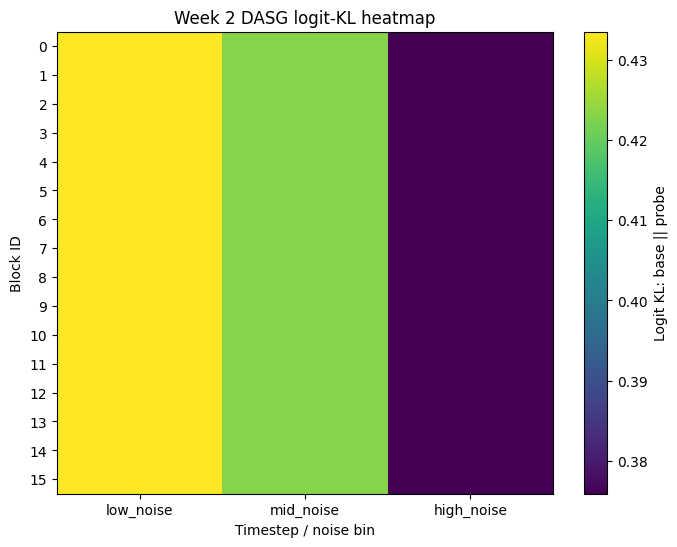

In [12]:
heatmap_df = target_layer_drift.copy()

hidden_pivot = heatmap_df.pivot_table(
    index="block_id",
    columns="noise_bin",
    values="hidden_drift_mse",
    aggfunc="mean",
)

hidden_pivot = hidden_pivot[NOISE_ORDER]

hidden_heatmap_path = OUT_DIR / "week2_hidden_drift_heatmap_values.csv"
hidden_pivot.to_csv(hidden_heatmap_path)

print("Saved:", hidden_heatmap_path)
display(hidden_pivot)

plt.figure(figsize=(8, 6))
plt.imshow(hidden_pivot.values, aspect="auto")
plt.colorbar(label="Hidden-state drift MSE")
plt.xticks(range(len(hidden_pivot.columns)), hidden_pivot.columns)
plt.yticks(range(len(hidden_pivot.index)), hidden_pivot.index)
plt.xlabel("Timestep / noise bin")
plt.ylabel("Block ID")
plt.title("Week 2 DASG hidden-state drift heatmap")
plt.show()

logit_pivot = target_layer_drift.pivot_table(
    index="block_id",
    columns="noise_bin",
    values="logit_kl_base_to_probe",
    aggfunc="mean",
)

logit_pivot = logit_pivot[NOISE_ORDER]
logit_heatmap_path = OUT_DIR / "week2_logit_kl_heatmap_values.csv"
logit_pivot.to_csv(logit_heatmap_path)

print("Saved:", logit_heatmap_path)
display(logit_pivot)

plt.figure(figsize=(8, 6))
plt.imshow(logit_pivot.values, aspect="auto")
plt.colorbar(label="Logit KL: base || probe")
plt.xticks(range(len(logit_pivot.columns)), logit_pivot.columns)
plt.yticks(range(len(logit_pivot.index)), logit_pivot.index)
plt.xlabel("Timestep / noise bin")
plt.ylabel("Block ID")
plt.title("Week 2 DASG logit-KL heatmap")
plt.show()

## 12. First fixed-vs-adaptive layer-selection experiment

This compares DASG-selected layers against fixed alternatives using a short LoRA adaptation run.


In [13]:
def eval_strategy_loss(model, method_name, selected_layers, phase):
    model.eval()
    rows = []

    eval_sets = [
        ("target_code_toy", TARGET_TEXTS),
        ("retention_general_toy", RETENTION_TEXTS),
    ]

    for domain, texts in eval_sets:
        for text in texts:
            for noise_bin in NOISE_ORDER:
                mask_prob = NOISE_BINS[noise_bin]
                input_ids, attention_mask = encode_text(text, model)
                noisy_ids, masked_indices = make_masked_input(input_ids, attention_mask, mask_prob)

                if torch.cuda.is_available():
                    torch.cuda.empty_cache()
                    torch.cuda.reset_peak_memory_stats()

                start = time.time()

                with torch.no_grad():
                    student_logits = forward_logits(model, noisy_ids).float()
                    with disable_adapters(model):
                        teacher_logits = forward_logits(model, noisy_ids).float()

                elapsed = time.time() - start

                weighted_loss, ce_loss = masked_weighted_ce(student_logits, input_ids, masked_indices, mask_prob)
                teacher_weighted_loss, teacher_ce_loss = masked_weighted_ce(teacher_logits, input_ids, masked_indices, mask_prob)

                rows.append({
                    "strategy": method_name,
                    "selected_layers": str(selected_layers),
                    "phase": phase,
                    "domain": domain,
                    "text": text,
                    "noise_bin": noise_bin,
                    "mask_prob": mask_prob,
                    "ce_loss": float(ce_loss.detach().cpu()),
                    "weighted_loss": float(weighted_loss.detach().cpu()),
                    "teacher_weighted_loss": float(teacher_weighted_loss.detach().cpu()),
                    "forgetting_vs_pretrained": float((weighted_loss - teacher_weighted_loss).detach().cpu()),
                    "teacher_agreement": teacher_agreement(student_logits, teacher_logits, masked_indices),
                    "masked_tokens": int(masked_indices.sum().item()),
                    "trainable_params": count_trainable_params(model),
                    "peak_gpu_memory_gb": gpu_mem_gb(),
                    "elapsed_sec": elapsed,
                })

    return rows


def train_strategy(model, strategy_name, selected_layers):
    model.train()
    optimizer = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=LR)
    rows = []

    for step in range(STRATEGY_TRAIN_STEPS):
        noise_bin = random.choice(NOISE_ORDER)
        target_text = random.choice(TARGET_TEXTS)
        retention_text = random.choice(RETENTION_TEXTS)

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats()

        start = time.time()

        target_loss, target_ce, target_masked = compute_target_loss(model, target_text, noise_bin)
        retention_kl, retention_masked = compute_retention_kl(model, retention_text, noise_bin)
        total_loss = target_loss + LAMBDA_RET * retention_kl

        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        elapsed = time.time() - start

        row = {
            "strategy": strategy_name,
            "selected_layers": str(selected_layers),
            "step": step,
            "noise_bin": noise_bin,
            "mask_prob": NOISE_BINS[noise_bin],
            "target_ce_loss": float(target_ce.detach().cpu()),
            "target_weighted_loss": float(target_loss.detach().cpu()),
            "retention_kl_loss": float(retention_kl.detach().cpu()),
            "total_loss": float(total_loss.detach().cpu()),
            "target_masked_tokens": target_masked,
            "retention_masked_tokens": retention_masked,
            "trainable_params": count_trainable_params(model),
            "peak_gpu_memory_gb": gpu_mem_gb(),
            "elapsed_sec": elapsed,
        }

        rows.append(row)
        print(row)

    return rows


num_blocks = len(ALL_LAYER_IDS)
all_layers_sorted = sorted(ALL_LAYER_IDS)

fixed_early = all_layers_sorted[:TOP_LAYER_BUDGET]
fixed_late = all_layers_sorted[-TOP_LAYER_BUDGET:]
fixed_middle_start = max(0, (num_blocks // 2) - (TOP_LAYER_BUDGET // 2))
fixed_middle = all_layers_sorted[fixed_middle_start:fixed_middle_start + TOP_LAYER_BUDGET]
uniform_idx = np.linspace(0, num_blocks - 1, TOP_LAYER_BUDGET).round().astype(int).tolist()
fixed_uniform = sorted({all_layers_sorted[i] for i in uniform_idx})
while len(fixed_uniform) < TOP_LAYER_BUDGET:
    for x in all_layers_sorted:
        if x not in fixed_uniform:
            fixed_uniform.append(x)
        if len(fixed_uniform) == TOP_LAYER_BUDGET:
            break

random.seed(SEED)
random_fixed = sorted(random.sample(all_layers_sorted, TOP_LAYER_BUDGET))

STRATEGIES = {
    "adaptive_dasg_top": selected_layers,
    "fixed_early": fixed_early,
    "fixed_middle": fixed_middle,
    "fixed_late": fixed_late,
    "fixed_uniform": fixed_uniform,
    "random_fixed": random_fixed,
}

print(json.dumps(STRATEGIES, indent=2))

{
  "adaptive_dasg_top": [
    15,
    14,
    13,
    12,
    11
  ],
  "fixed_early": [
    0,
    1,
    2,
    3,
    4
  ],
  "fixed_middle": [
    6,
    7,
    8,
    9,
    10
  ],
  "fixed_late": [
    11,
    12,
    13,
    14,
    15
  ],
  "fixed_uniform": [
    0,
    4,
    8,
    11,
    15
  ],
  "random_fixed": [
    0,
    3,
    4,
    11,
    15
  ]
}


## 13. Run fixed-vs-adaptive experiment

On T4 this can take a while. To make it faster, reduce `STRATEGY_TRAIN_STEPS` to 1 or test only `adaptive_dasg_top` and `random_fixed`.


In [14]:
strategy_eval_rows = []
strategy_train_rows = []
strategy_meta = []

for strategy_name, layers in STRATEGIES.items():
    print("=" * 100)
    print("Starting strategy:", strategy_name)
    print("Layers:", layers)

    cleanup_model()
    model = load_base_model()
    target_modules = attach_probe_lora(model, layers)

    strategy_meta.append({
        "strategy": strategy_name,
        "layers": layers,
        "num_target_modules": len(target_modules),
        "target_modules_sample": target_modules[:10],
        "trainable_params": count_trainable_params(model),
    })

    before_rows = eval_strategy_loss(model, strategy_name, layers, phase="before")
    train_rows = train_strategy(model, strategy_name, layers)
    after_rows = eval_strategy_loss(model, strategy_name, layers, phase="after")

    strategy_eval_rows.extend(before_rows)
    strategy_eval_rows.extend(after_rows)
    strategy_train_rows.extend(train_rows)

    pd.DataFrame(strategy_eval_rows).to_csv(OUT_DIR / "week2_fixed_vs_adaptive_eval_partial.csv", index=False)
    pd.DataFrame(strategy_train_rows).to_csv(OUT_DIR / "week2_fixed_vs_adaptive_train_partial.csv", index=False)

    cleanup_model()

strategy_eval_df = pd.DataFrame(strategy_eval_rows)
strategy_train_df = pd.DataFrame(strategy_train_rows)

strategy_eval_path = OUT_DIR / "week2_fixed_vs_adaptive_eval_log.csv"
strategy_train_path = OUT_DIR / "week2_fixed_vs_adaptive_train_log.csv"
strategy_meta_path = OUT_DIR / "week2_fixed_vs_adaptive_meta.json"

strategy_eval_df.to_csv(strategy_eval_path, index=False)
strategy_train_df.to_csv(strategy_train_path, index=False)

with open(strategy_meta_path, "w") as f:
    json.dump(strategy_meta, f, indent=2)

print("Saved:", strategy_eval_path)
print("Saved:", strategy_train_path)
print("Saved:", strategy_meta_path)
display(strategy_eval_df.head())
display(strategy_train_df.head())

Starting strategy: adaptive_dasg_top
Layers: [15, 14, 13, 12, 11]


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


{'strategy': 'adaptive_dasg_top', 'selected_layers': '[15, 14, 13, 12, 11]', 'step': 0, 'noise_bin': 'low_noise', 'mask_prob': 0.15, 'target_ce_loss': 1.930382251739502, 'target_weighted_loss': 12.86921501159668, 'retention_kl_loss': 0.0001645972952246666, 'total_loss': 12.86929702758789, 'target_masked_tokens': 2, 'retention_masked_tokens': 1, 'trainable_params': 327680, 'peak_gpu_memory_gb': 8.924055099487305, 'elapsed_sec': 5.594741344451904}
{'strategy': 'adaptive_dasg_top', 'selected_layers': '[15, 14, 13, 12, 11]', 'step': 1, 'noise_bin': 'low_noise', 'mask_prob': 0.15, 'target_ce_loss': 0.9795860052108765, 'target_weighted_loss': 6.53057336807251, 'retention_kl_loss': 0.04252207651734352, 'total_loss': 6.551834583282471, 'target_masked_tokens': 2, 'retention_masked_tokens': 1, 'trainable_params': 327680, 'peak_gpu_memory_gb': 8.914149761199951, 'elapsed_sec': 3.4377825260162354}
{'strategy': 'adaptive_dasg_top', 'selected_layers': '[15, 14, 13, 12, 11]', 'step': 2, 'noise_bin': 

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

...

{'strategy': 'fixed_uniform', 'selected_layers': '[0, 4, 8, 11, 15]', 'step': 0, 'noise_bin': 'mid_noise', 'mask_prob': 0.5, 'target_ce_loss': 2.028282403945923, 'target_weighted_loss': 4.056564807891846, 'retention_kl_loss': 0.13493317365646362, 'total_loss': 4.1240315437316895, 'target_masked_tokens': 4, 'retention_masked_tokens': 11, 'trainable_params': 327680, 'peak_gpu_memory_gb': 8.994935512542725, 'elapsed_sec': 4.298007011413574}
{'strategy': 'fixed_uniform', 'selected_layers': '[0, 4, 8, 11, 15]', 'step': 1, 'noise_bin': 'mid_noise', 'mask_prob': 0.5, 'target_ce_loss': 2.8700876235961914, 'target_weighted_loss': 5.740175247192383, 'retention_kl_loss': 0.11197073757648468, 'total_loss': 5.796160697937012, 'target_masked_tokens': 6, 'retention_masked_tokens': 5, 'trainable_params': 327680, 'peak_gpu_memory_gb': 8.984089374542236, 'elapsed_sec': 5.349628925323486}
{'strategy': 'fixed_uniform', 'selected_layers': '[0, 4, 8, 11, 15]', 'step': 2, 'noise_bin': 'low_noise', 'mask_prob

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

{'strategy': 'random_fixed', 'selected_layers': '[0, 3, 4, 11, 15]', 'step': 0, 'noise_bin': 'low_noise', 'mask_prob': 0.15, 'target_ce_loss': 0.0008255410939455032, 'target_weighted_loss': 0.005503606982529163, 'retention_kl_loss': 0.1537589430809021, 'total_loss': 0.08238308131694794, 'target_masked_tokens': 1, 'retention_masked_tokens': 2, 'trainable_params': 327680, 'peak_gpu_memory_gb': 8.945299625396729, 'elapsed_sec': 4.548532724380493}
{'strategy': 'random_fixed', 'selected_layers': '[0, 3, 4, 11, 15]', 'step': 1, 'noise_bin': 'high_noise', 'mask_prob': 0.85, 'target_ce_loss': 8.853571891784668, 'target_weighted_loss': 10.415966987609863, 'retention_kl_loss': 0.40215733647346497, 'total_loss': 10.617045402526855, 'target_masked_tokens': 9, 'retention_masked_tokens': 13, 'trainable_params': 327680, 'peak_gpu_memory_gb': 9.01057481765747, 'elapsed_sec': 3.805233955383301}
{'strategy': 'random_fixed', 'selected_layers': '[0, 3, 4, 11, 15]', 'step': 2, 'noise_bin': 'high_noise', 'm

,strategy,selected_layers,phase,domain,text,noise_bin,mask_prob,ce_loss,weighted_loss,teacher_weighted_loss,forgetting_vs_pretrained,teacher_agreement,masked_tokens,trainable_params,peak_gpu_memory_gb,elapsed_sec
0,adaptive_dasg_top,"[15, 14, 13, 12, 11]",before,target_code_toy,"def add_numbers(a, b): return a + b",low_noise,0.15,3.766706,25.111374,25.111374,0.0,1.0,3,327680,8.894629,1.694788
1,adaptive_dasg_top,"[15, 14, 13, 12, 11]",before,target_code_toy,"def add_numbers(a, b): return a + b",mid_noise,0.50,4.461998,8.923996,8.923996,0.0,1.0,4,327680,8.900777,2.150011
2,adaptive_dasg_top,"[15, 14, 13, 12, 11]",before,target_code_toy,"def add_numbers(a, b): return a + b",high_noise,0.85,8.225065,9.676548,9.676548,0.0,1.0,9,327680,8.901657,1.777119
3,adaptive_dasg_top,"[15, 14, 13, 12, 11]",before,target_code_toy,for i in range(n): total += arr[i],low_noise,0.15,1.975544,13.170296,13.170296,0.0,1.0,1,327680,8.900777,1.688063
4,adaptive_dasg_top,"[15, 14, 13, 12, 11]",before,target_code_toy,for i in range(n): total += arr[i],mid_noise,0.50,1.806490,3.612981,3.612981,0.0,1.0,3,327680,8.900777,1.678865


,strategy,selected_layers,step,noise_bin,mask_prob,target_ce_loss,target_weighted_loss,retention_kl_loss,total_loss,target_masked_tokens,retention_masked_tokens,trainable_params,peak_gpu_memory_gb,elapsed_sec
0,adaptive_dasg_top,"[15, 14, 13, 12, 11]",0,low_noise,0.15,1.930382,12.869215,0.000165,12.869297,2,1,327680,8.924055,5.594741
1,adaptive_dasg_top,"[15, 14, 13, 12, 11]",1,low_noise,0.15,0.979586,6.530573,0.042522,6.551835,2,1,327680,8.914150,3.437783
2,adaptive_dasg_top,"[15, 14, 13, 12, 11]",2,high_noise,0.85,7.350064,8.647135,0.011192,8.652731,11,6,327680,8.935978,2.864413
3,fixed_early,"[0, 1, 2, 3, 4]",0,low_noise,0.15,0.104052,0.693681,0.000244,0.693803,2,1,327680,8.939683,4.943630
4,fixed_early,"[0, 1, 2, 3, 4]",1,low_noise,0.15,8.210254,54.735023,0.462659,54.966354,1,3,327680,8.981845,5.028660


## 14. Summarize fixed-vs-adaptive results

In [15]:
phase_summary = (
    strategy_eval_df
    .groupby(["strategy", "selected_layers", "domain", "phase"])
    .agg(
        mean_weighted_loss=("weighted_loss", "mean"),
        mean_ce_loss=("ce_loss", "mean"),
        mean_forgetting_vs_pretrained=("forgetting_vs_pretrained", "mean"),
        mean_teacher_agreement=("teacher_agreement", "mean"),
        max_gpu_memory_gb=("peak_gpu_memory_gb", "max"),
        trainable_params=("trainable_params", "max"),
    )
    .reset_index()
)

phase_summary_path = OUT_DIR / "week2_fixed_vs_adaptive_phase_summary.csv"
phase_summary.to_csv(phase_summary_path, index=False)

print("Saved:", phase_summary_path)
display(phase_summary)

pivot = phase_summary.pivot_table(
    index=["strategy", "selected_layers", "domain"],
    columns="phase",
    values="mean_weighted_loss",
).reset_index()

pivot["loss_change_after_minus_before"] = pivot["after"] - pivot["before"]

loss_change_path = OUT_DIR / "week2_fixed_vs_adaptive_loss_change.csv"
pivot.to_csv(loss_change_path, index=False)

print("Saved:", loss_change_path)
display(pivot)

target_rows = pivot[pivot["domain"] == "target_code_toy"].copy()
retention_rows = pivot[pivot["domain"] == "retention_general_toy"].copy()

proxy = target_rows.merge(
    retention_rows,
    on=["strategy", "selected_layers"],
    suffixes=("_target", "_retention"),
)

proxy = proxy[[
    "strategy",
    "selected_layers",
    "loss_change_after_minus_before_target",
    "loss_change_after_minus_before_retention",
]]

proxy = proxy.sort_values(
    ["loss_change_after_minus_before_target", "loss_change_after_minus_before_retention"],
    ascending=[True, True],
)

proxy_path = OUT_DIR / "week2_fixed_vs_adaptive_proxy_table.csv"
proxy.to_csv(proxy_path, index=False)

print("Saved:", proxy_path)
display(proxy)

Saved: /content/week2_dasg_drift_probes/week2_fixed_vs_adaptive_phase_summary.csv


,strategy,selected_layers,domain,phase,mean_weighted_loss,mean_ce_loss,mean_forgetting_vs_pretrained,mean_teacher_agreement,max_gpu_memory_gb,trainable_params
0,adaptive_dasg_top,"[15, 14, 13, 12, 11]",retention_general_toy,after,9.392104,4.174481,0.105229,0.987654,8.909904,327680
1,adaptive_dasg_top,"[15, 14, 13, 12, 11]",retention_general_toy,before,8.778229,4.701359,0.000000,1.000000,8.909854,327680
2,adaptive_dasg_top,"[15, 14, 13, 12, 11]",target_code_toy,after,11.025994,4.208597,-0.008568,0.988889,8.907562,327680
3,adaptive_dasg_top,"[15, 14, 13, 12, 11]",target_code_toy,before,7.580330,3.620427,0.000000,1.000000,8.905170,327680
4,fixed_early,"[0, 1, 2, 3, 4]",retention_general_toy,after,9.032832,4.532917,0.672004,0.828992,8.909904,327680
5,fixed_early,"[0, 1, 2, 3, 4]",retention_general_toy,before,7.837354,4.244303,0.000000,1.000000,8.909854,327680
6,fixed_early,"[0, 1, 2, 3, 4]",target_code_toy,after,7.600928,3.803746,-0.639187,0.621693,8.908733,327680
7,fixed_early,"[0, 1, 2, 3, 4]",target_code_toy,before,6.368322,3.465671,0.000000,1.000000,8.906341,327680
8,fixed_late,"[11, 12, 13, 14, 15]",retention_general_toy,after,10.643681,4.959025,-0.058869,1.000000,8.908733,327680
9,fixed_late,"[11, 12, 13, 14, 15]",retention_general_toy,before,14.270311,5.403728,0.000000,1.000000,8.908683,327680


Saved: /content/week2_dasg_drift_probes/week2_fixed_vs_adaptive_loss_change.csv


phase,strategy,selected_layers,domain,after,before,loss_change_after_minus_before
0,adaptive_dasg_top,"[15, 14, 13, 12, 11]",retention_general_toy,9.392104,8.778229,0.613876
1,adaptive_dasg_top,"[15, 14, 13, 12, 11]",target_code_toy,11.025994,7.580330,3.445665
2,fixed_early,"[0, 1, 2, 3, 4]",retention_general_toy,9.032832,7.837354,1.195478
3,fixed_early,"[0, 1, 2, 3, 4]",target_code_toy,7.600928,6.368322,1.232606
4,fixed_late,"[11, 12, 13, 14, 15]",retention_general_toy,10.643681,14.270311,-3.626631
5,fixed_late,"[11, 12, 13, 14, 15]",target_code_toy,6.545703,9.945364,-3.399662
6,fixed_middle,"[6, 7, 8, 9, 10]",retention_general_toy,14.143025,8.021393,6.121633
7,fixed_middle,"[6, 7, 8, 9, 10]",target_code_toy,8.780656,5.721160,3.059496
8,fixed_uniform,"[0, 4, 8, 11, 15]",retention_general_toy,12.748589,9.245161,3.503427
9,fixed_uniform,"[0, 4, 8, 11, 15]",target_code_toy,8.217799,9.214974,-0.997175


Saved: /content/week2_dasg_drift_probes/week2_fixed_vs_adaptive_proxy_table.csv


phase,strategy,selected_layers,loss_change_after_minus_before_target,loss_change_after_minus_before_retention
2,fixed_late,"[11, 12, 13, 14, 15]",-3.399662,-3.626631
4,fixed_uniform,"[0, 4, 8, 11, 15]",-0.997175,3.503427
1,fixed_early,"[0, 1, 2, 3, 4]",1.232606,1.195478
3,fixed_middle,"[6, 7, 8, 9, 10]",3.059496,6.121633
0,adaptive_dasg_top,"[15, 14, 13, 12, 11]",3.445665,0.613876
5,random_fixed,"[0, 3, 4, 11, 15]",3.852998,-0.777245


## 15. Plot fixed-vs-adaptive proxy table

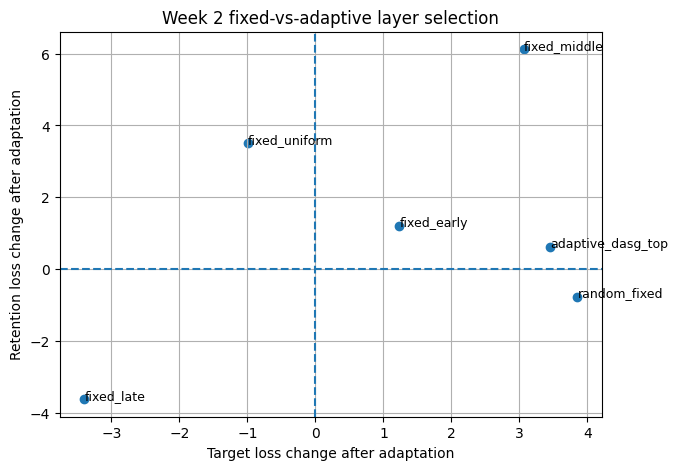

In [16]:
plt.figure(figsize=(7, 5))

plt.scatter(
    proxy["loss_change_after_minus_before_target"],
    proxy["loss_change_after_minus_before_retention"],
)

for _, row in proxy.iterrows():
    plt.text(
        row["loss_change_after_minus_before_target"],
        row["loss_change_after_minus_before_retention"],
        row["strategy"],
        fontsize=9,
    )

plt.axvline(0, linestyle="--")
plt.axhline(0, linestyle="--")
plt.xlabel("Target loss change after adaptation")
plt.ylabel("Retention loss change after adaptation")
plt.title("Week 2 fixed-vs-adaptive layer selection")
plt.grid(True)
plt.show()

## 16. Save Week 2 reproducibility report

In [17]:
best_strategy = proxy.iloc[0]["strategy"] if len(proxy) else None

report = {
    "week": 2,
    "task": "DASG drift probes and first fixed-vs-adaptive layer selection",
    "model": MODEL_NAME,
    "gpu": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
    "quantization": "4-bit NF4",
    "max_length": MAX_LENGTH,
    "noise_bins": NOISE_BINS,
    "probe_train_steps": PROBE_TRAIN_STEPS,
    "strategy_train_steps": STRATEGY_TRAIN_STEPS,
    "lora_rank": LORA_RANK,
    "lambda_ret": LAMBDA_RET,
    "selected_layers": selected_layers,
    "best_fixed_vs_adaptive_proxy_strategy": best_strategy,
    "outputs": {
        "probe_train_log": str(probe_train_path),
        "drift_scores": str(drift_path),
        "layer_ranking": str(rank_path),
        "selected_grown_layers": str(selection_path),
        "hidden_drift_heatmap_values": str(hidden_heatmap_path),
        "logit_kl_heatmap_values": str(logit_heatmap_path),
        "fixed_vs_adaptive_eval_log": str(strategy_eval_path),
        "fixed_vs_adaptive_train_log": str(strategy_train_path),
        "fixed_vs_adaptive_phase_summary": str(phase_summary_path),
        "fixed_vs_adaptive_loss_change": str(loss_change_path),
        "fixed_vs_adaptive_proxy_table": str(proxy_path),
    },
    "notes": (
        "Hidden-state drift is computed layer-wise between adapter-disabled frozen path and adapted LoRA probe. "
        "Logit KL is computed on masked tokens for each timestep/noise bin. "
        "Layer ranking uses normalized hidden drift plus a smaller logit-KL term. "
        "The fixed-vs-adaptive experiment compares the DASG-ranked layers against early, middle, late, uniform, and random layer choices."
    ),
}

report_path = OUT_DIR / "week2_reproducibility_report.json"
with open(report_path, "w") as f:
    json.dump(report, f, indent=2)

print("Saved:", report_path)
print(json.dumps(report, indent=2))

Saved: /content/week2_dasg_drift_probes/week2_reproducibility_report.json
{
  "week": 2,
  "task": "DASG drift probes and first fixed-vs-adaptive layer selection",
  "model": "inclusionAI/LLaDA-MoE-7B-A1B-Instruct",
  "gpu": "Tesla T4",
  "quantization": "4-bit NF4",
  "max_length": 32,
  "noise_bins": {
    "low_noise": 0.15,
    "mid_noise": 0.5,
    "high_noise": 0.85
  },
  "probe_train_steps": 5,
  "strategy_train_steps": 3,
  "lora_rank": 4,
  "lambda_ret": 0.5,
  "selected_layers": [
    15,
    14,
    13,
    12,
    11
  ],
  "best_fixed_vs_adaptive_proxy_strategy": "fixed_late",
  "outputs": {
    "probe_train_log": "/content/week2_dasg_drift_probes/week2_lora_probe_train_log.csv",
    "drift_scores": "/content/week2_dasg_drift_probes/week2_drift_scores.csv",
    "layer_ranking": "/content/week2_dasg_drift_probes/week2_layer_ranking.csv",
    "selected_grown_layers": "/content/week2_dasg_drift_probes/selected_grown_layers.json",
    "hidden_drift_heatmap_values": "/content/w

Week 2 implemented the DASG drift-probe pipeline on top of the Week 1 LLaDA-family baseline. A warm-start LoRA probe was trained on the toy target-code domain while retaining the frozen-base path through adapter disabling. Hidden-state drift was computed layer-wise by measuring mean-squared differences between frozen-path and adapted-path hidden states across valid tokens. Logit KL drift was computed on masked token positions by comparing the frozen/base output distribution against the adapted probe output distribution. Both drift signals were logged across low, mid, and high timestep/noise bins. The resulting drift scores were aggregated into a layer-ranking table and exported as selected_grown_layers.json. Week 2 also ran a first fixed-vs-adaptive layer-selection experiment, comparing DASG-selected layers against early, middle, late, uniform, and random selections using matched short LoRA adaptation runs. Outputs include drift-score logs, hidden-drift and logit-KL heatmap values, a layer-ranking table, fixed-vs-adaptive evaluation logs, a proxy comparison table, and a reproducibility report.